<a href="https://colab.research.google.com/github/EfiDefiyati/Modul-Praktikum-Deep-Learning/blob/main/M01_123450005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Efi Defiyati

**NIM:** 123450005  
**Kelas:** RC  
**Tanggal:** 2026-09-15  

**Berkas pengumpulan:** `M01_NIM.ipynb`, `M01_NIM.pdf`, dan `M01_NIM_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [1]:
pip install torch numpy pandas scikit-learn matplotlib

In [16]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '123450005'
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.15',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'sklearn': '1.6.1',
 'torch': '2.11.0+cu128',
 'device': 'cuda',
 'seed': 1005}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** Parameter adalah nilai yang dipelajari oleh model selama proses training, seperti bobot dan bias. Sedangkan hyperparameter adalah nilai yang ditentukan sebelum training, seperti learning rate, batch size, jumlah epoch, hidden size, dan jenis fungsi aktivasi.
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** Tumpukan layer affine tanpa fungsi aktivasi dapat digabung menjadi satu layer affine karena komposisi dari beberapa operasi linear atau affine tetap menghasilkan transformasi affine. Oleh karena itu, tanpa fungsi aktivasi non-linear, penambahan layer tidak memberikan kemampuan untuk mempelajari pola yang lebih kompleks.
3. **Shape bobot layer 2 masukan -> 8 keluaran:** Bobot layer dengan 2 masukan dan 8 keluaran memiliki shape (8, 2), sedangkan bias-nya memiliki shape (8,).
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** BCEWithLogitsLoss menerima logit karena fungsi tersebut sudah menggabungkan sigmoid dengan binary cross-entropy sehingga perhitungannya lebih stabil secara numerik. Oleh karena itu, sigmoid tidak perlu ditambahkan pada output model.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** Prediksi ReLU dengan hidden size lebih besar (16) diprediksi memberi validation loss terbaik. Alasannya, ReLU tidak mengalami saturasi pada nilai positif besar seperti sigmoid/tanh sehingga gradiennya tetap besar dan training dengan SGD polos (tanpa momentum/adaptif) akan konvergen lebih cepat dalam 200 epoch. Hidden size lebih besar memberi kapasitas representasi lebih tinggi untuk memisahkan pola non-linear pada `make_moons`, sehingga berpotensi menurunkan validation loss selama tidak overfitting parah pada dataset sekecil ini.

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [17]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    return np.where(z > 0, z, alpha * z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    X = np.asarray(X, dtype=float)
    w = np.asarray(w, dtype=float)
    assert X.ndim == 2 and w.ndim == 1 and X.shape[1] == w.shape[0], (
        f'Shape tidak cocok: X{X.shape} vs w{w.shape}'
    )
    z = X @ w + b
    a = activation(z)
    return z, a

# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


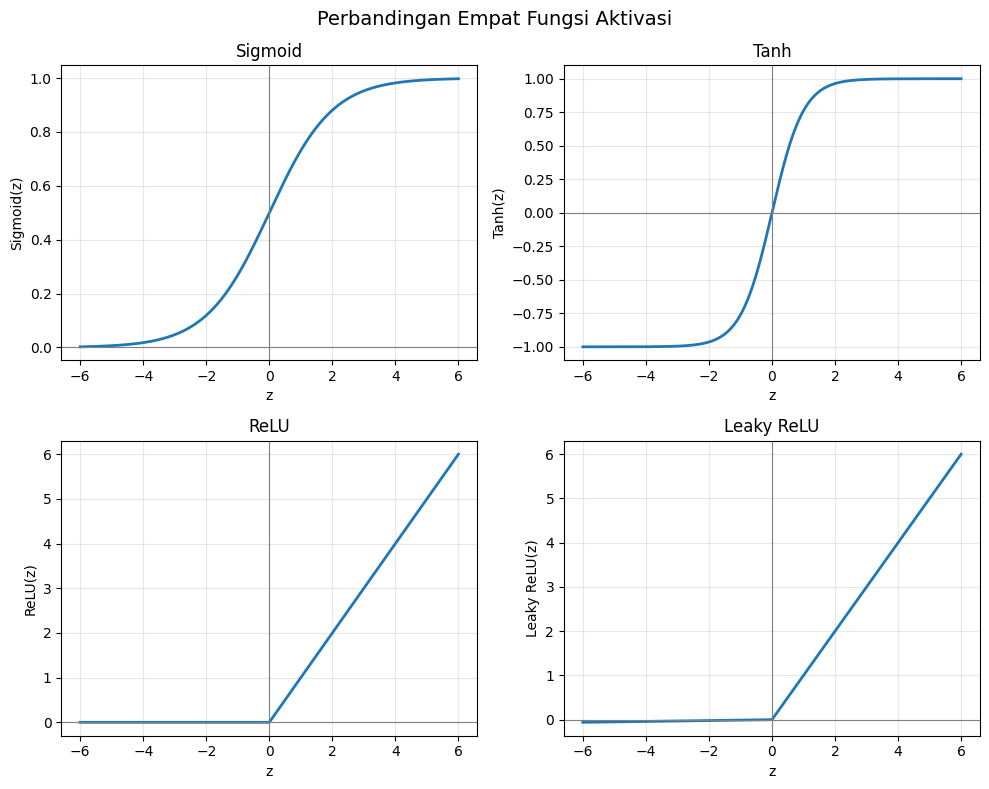

In [18]:
grid = np.linspace(-6, 6, 600)
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, values) in zip(axes.ravel(), activation_values.items()):
    ax.plot(grid, values, color='tab:blue', linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('z')
    ax.set_ylabel(f'{name}(z)')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.grid(alpha=0.3)
fig.suptitle('Perbandingan Empat Fungsi Aktivasi', fontsize=14)
fig.tight_layout()
plt.show()

### Interpretasi aktivasi

- Aktivasi yang berpusat di nol: Fungsi aktivasi yang berpusat di nol adalah - **Aktivasi yang berpusat di nol:** Tanh (rentang keluaran -1 hingga 1, simetris terhadap 0). Sigmoid dan ReLU tidak berpusat di nol (rentang keluarannya masing-masing (0,1) dan [0,∞)).
- **Aktivasi yang tepat nol untuk masukan negatif:** ReLU, karena `ReLU(z) = max(0, z)` sehingga untuk semua `z < 0` keluarannya persis 0 (Leaky ReLU untuk `z<0` mendekati nol tetapi tidak persis nol karena masih ada kemiringan kecil `alpha*z`).
- **Aktivasi yang mudah jenuh (saturasi):** Sigmoid dan Tanh, karena gradiennya mendekati nol saat `|z|` besar (kurva menjadi hampir datar di kedua ujung), yang dapat menyebabkan *vanishing gradient*.
- **Mengapa aktivasi linear tidak cukup untuk `make_moons`:** Seperti dibahas pada Pre-lab, tumpukan transformasi linear/affine tetap menghasilkan satu batas keputusan linear (garis lurus). Dataset `make_moons` memiliki dua kelas berbentuk bulan sabit yang saling melingkupi dan **tidak dapat dipisahkan oleh satu garis lurus**, sehingga dibutuhkan fungsi aktivasi non-linear agar jaringan bisa membentuk batas keputusan lengkung yang memisahkan kedua kelas dengan baik.

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [19]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

z1_np = x_manual @ W1.T + b1
h_np = relu_np(z1_np)
logit_np = h_np @ W2.T + b2
prob_np = sigmoid_np(logit_np)
eps = 1e-12
bce_np = -(y_manual * np.log(prob_np + eps) + (1 - y_manual) * np.log(1 - prob_np + eps))

parameter_count_manual = W1.size + b1.size + W2.size + b2.size

print('z1  =', z1_np)
print('h   =', h_np)
print('logit =', logit_np)
print('prob  =', prob_np)
print('BCE   =', bce_np)
print('Jumlah parameter =', parameter_count_manual)

z1  = [[1.5 1. ]]
h   = [[1.5 1. ]]
logit = [[2.5]]
prob  = [[0.92414182]]
BCE   = [[0.07888973]]
Jumlah parameter = 9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | (1, 2) | [[2.0, -1.0]] |
| $W^{(1)}$ | (2, 2) | tersedia pada kode |
| $z^{(1)}$ | (1, 2) | [[1.5, 1.0]] |
| $h$ | (1, 2) | [[1.5, 1.0]] |
| logit | (1, 1) | [[2.5]] |
| probabilitas | 	(1, 1) | [[0.9241]] |
| BCE | skalar | 0.0789
 |

**Jumlah parameter dan perhitungannya:** `W1` (2×2=4) + `b1` (2) + `W2` (1×2=2) + `b2` (1) = **9 parameter**.

Perhitungan manual: `z1 = x @ W1.T + b1`. Untuk neuron hidden pertama: `2*0.5 + (-1)*(-0.5) = 1 + 0.5 = 1.5`. Untuk neuron hidden kedua: `2*1.0 + (-1)*1.0 = 2 - 1 = 1.0`. Karena kedua nilai positif, ReLU tidak mengubahnya, sehingga `h = [1.5, 1.0]`. Logit keluaran: `1.5*2 + 1.0*(-1) + 0.5 = 3 - 1 + 0.5 = 2.5`. Probabilitas: `sigmoid(2.5) ≈ 0.9241`. Karena target `y=1`, BCE `= -log(0.9241) ≈ 0.0789`, nilai yang kecil karena model sudah cukup yakin dan benar terhadap label sebenarnya.

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [20]:
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

with torch.no_grad():
    manual_model[0].weight.copy_(torch.tensor(W1))
    manual_model[0].bias.copy_(torch.tensor(b1))
    manual_model[2].weight.copy_(torch.tensor(W2))
    manual_model[2].bias.copy_(torch.tensor(b2))

x_tensor = torch.tensor(x_manual)
y_tensor = torch.tensor(y_manual)

torch_logit = manual_model(x_tensor)
torch_probability = torch.sigmoid(torch_logit)
torch_loss = nn.functional.binary_cross_entropy_with_logits(torch_logit, y_tensor)

assert np.max(np.abs(torch_logit.detach().numpy() - logit_np)) < 1e-6
assert abs(torch_loss.item() - float(bce_np.squeeze())) < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual

print('Logit PyTorch      :', torch_logit.item())
print('Probabilitas PyTorch:', torch_probability.item())
print('Loss PyTorch (BCE)  :', torch_loss.item())
print('Semua assertion pencocokan NumPy <-> PyTorch LULUS.')

Logit PyTorch      : 2.5
Probabilitas PyTorch: 0.9241418242454529
Loss PyTorch (BCE)  : 0.07888973504304886
Semua assertion pencocokan NumPy <-> PyTorch LULUS.


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:**

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


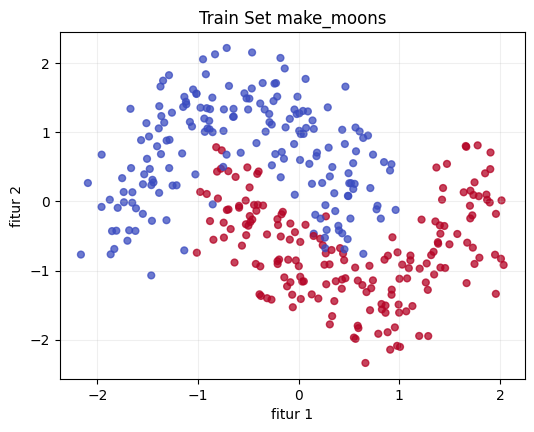

In [21]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** Mengapa scaler hanya di-fit pada train set dan bukan seluruh data: StandardScaler menghitung mean dan standar deviasi dari data yang diberikan lalu memakainya untuk menstandardisasi. Jika scaler di-fit pada seluruh data (termasuk validation/test), statistik (mean, std) dari sampel validation dan test akan "bocor" (leak) ke dalam proses training, model secara tidak langsung mendapat informasi tentang distribusi data yang seharusnya belum pernah ia lihat. Hal tersebut membuat estimasi performa pada validation/test menjadi terlalu optimis dan tidak mencerminkan performa nyata pada data baru. Dengan hanya fit pada train set lalu men-*transform* validation dan test menggunakan statistik yang sama,  mensimulasikan kondisi dunia nyata, model hanya boleh belajar dari data yang tersedia saat training, dan data baru diperlakukan dengan aturan yang sudah "dibekukan" dari data training tersebut.

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [22]:
def activation_layer(name: str) -> nn.Module:
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    elif name == 'tanh':
        return nn.Tanh()
    elif name == 'sigmoid':
        return nn.Sigmoid()
    else:
        raise ValueError(f'Aktivasi tidak dikenal: {name}')

def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)
    model = nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1),
    )
    return model.to(DEVICE)

def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())

# Buat model 2 -> 8 -> 1 dan buktikan jumlah parameternya 4h+1 = 33.
model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33
print('Jumlah parameter model 2->8->1:', count_parameters(model_check), '(sesuai rumus 4h+1 = 4*8+1 = 33)')

Jumlah parameter model 2->8->1: 33 (sesuai rumus 4h+1 = 4*8+1 = 33)


In [23]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** NIM saya (123450005) berakhiran digit 5, sehingga latihan individual memakai sigmoid. Sigmoid mudah jenuh (gradiennya kecil saat |z| besar) dan tidak berpusat di nol, sehingga diprediksi konvergensinya lebih lambat dan validation loss akhirnya sedikit lebih tinggi dibanding baseline ReLU dengan hidden size yang sama (8).

In [ ]:
# TODO: latih baseline, tampilkan kurva train/validation loss, dan catat metrik.
# TODO: latih satu variasi individual dengan komponen lain tetap.
raise NotImplementedError('Selesaikan baseline dan latihan individual.')

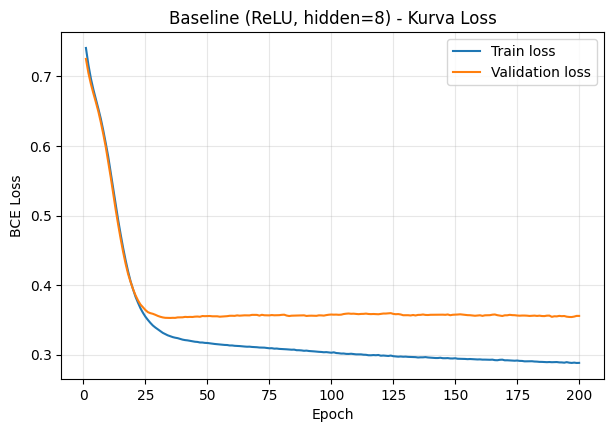

Baseline (ReLU, h=8) - val_loss akhir: 0.3559, val_accuracy akhir: 0.8583, waktu training: 4.15s


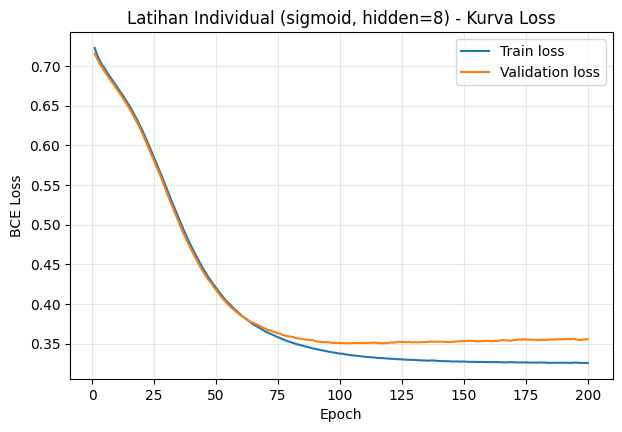

Digit terakhir NIM = 5 -> aktivasi individual = 'sigmoid'
Individual (sigmoid, h=8) - val_loss akhir: 0.3557, val_accuracy akhir: 0.8500, waktu training: 3.24s


In [24]:
baseline_model = build_model(8, 'relu')
baseline_history, baseline_time = train_model(baseline_model)
baseline_val = evaluate(baseline_model, X_val_t, y_val_t)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(baseline_history['epoch'], baseline_history['train_loss'], label='Train loss')
ax.plot(baseline_history['epoch'], baseline_history['val_loss'], label='Validation loss')
ax.set(title='Baseline (ReLU, hidden=8) - Kurva Loss', xlabel='Epoch', ylabel='BCE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Baseline (ReLU, h=8) - val_loss akhir: {baseline_history.iloc[-1]['val_loss']:.4f}, "
      f"val_accuracy akhir: {baseline_history.iloc[-1]['val_accuracy']:.4f}, "
      f"waktu training: {baseline_time:.2f}s")

last_digit = NIM_LAST4 % 10
individual_activation = 'tanh' if last_digit <= 4 else 'sigmoid'
individual_model = build_model(8, individual_activation)
individual_history, individual_time = train_model(individual_model)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(individual_history['epoch'], individual_history['train_loss'], label='Train loss')
ax.plot(individual_history['epoch'], individual_history['val_loss'], label='Validation loss')
ax.set(title=f'Latihan Individual ({individual_activation}, hidden=8) - Kurva Loss', xlabel='Epoch', ylabel='BCE Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Digit terakhir NIM = {last_digit} -> aktivasi individual = '{individual_activation}'")
print(f"Individual ({individual_activation}, h=8) - val_loss akhir: {individual_history.iloc[-1]['val_loss']:.4f}, "
      f"val_accuracy akhir: {individual_history.iloc[-1]['val_accuracy']:.4f}, "
      f"waktu training: {individual_time:.2f}s")

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [25]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models = {}
histories = {}

for activation in ACTIVATIONS:
    for hidden_size in HIDDEN_SIZES:
        run_id = f'{activation}_h{hidden_size}'
        model = build_model(hidden_size, activation)
        history, train_time = train_model(
            model, epochs=EPOCHS, learning_rate=LEARNING_RATE, batch_size=BATCH_SIZE
        )
        train_metrics = evaluate(model, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
        val_metrics = evaluate(model, X_val_t, y_val_t)

        trained_models[run_id] = model
        histories[run_id] = history
        experiment_rows.append({
            'run_id': run_id,
            'activation': activation,
            'hidden_size': hidden_size,
            'n_params': count_parameters(model),
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'train_time_sec': train_time,
        })

results = pd.DataFrame(experiment_rows).sort_values('val_loss').reset_index(drop=True)
assert len(results) == 6
display(results)

,run_id,activation,hidden_size,n_params,train_loss,train_accuracy,val_loss,val_accuracy,train_time_sec
0,tanh_h16,tanh,16,65,0.1870,0.9250,0.2453,0.9167,3.4722
1,relu_h16,relu,16,65,0.2009,0.9167,0.2558,0.9000,3.2044
2,tanh_h4,tanh,4,17,0.2288,0.9111,0.2750,0.9083,3.2855
3,sigmoid_h4,sigmoid,4,17,0.3304,0.8500,0.3551,0.8500,3.1520
4,sigmoid_h16,sigmoid,16,65,0.3229,0.8528,0.3555,0.8500,3.2472
5,relu_h4,relu,4,17,0.3026,0.8611,0.3585,0.8500,3.1838


In [26]:
best_run_id_preview = results.iloc[0]['run_id']

split_description = (
    f'train={len(y_train)} ({len(y_train)/len(y):.0%}), '
    f'val={len(y_val)} ({len(y_val)/len(y):.0%}), '
    f'test={len(y_test)} ({len(y_test)/len(y):.0%}), stratified'
)

metrics_rows = []
for row in results.itertuples():
    metrics_rows.append({
        'run_id': row.run_id,
        'module': 'M01',
        'student_id': NIM,
        'seed': SEED,
        'dataset': 'make_moons(n_samples=600, noise=0.22)',
        'split': split_description,
        'model': f'FNN(2-{row.hidden_size}-1)',
        'optimizer': 'SGD',
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'train_loss': row.train_loss,
        'val_loss': row.val_loss,
        'val_metric': row.val_accuracy,
        'test_metric': np.nan,
        'parameters': row.n_params,
        'trainable_parameters': row.n_params,
        'runtime_seconds': row.train_time_sec,
        'device': str(DEVICE),
        'notes': f'activation={row.activation}; hidden_size={row.hidden_size}',
    })

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

,run_id,module,student_id,seed,dataset,split,model,optimizer,learning_rate,batch_size,epochs,train_loss,val_loss,val_metric,test_metric,parameters,trainable_parameters,runtime_seconds,device,notes
0,tanh_h16,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-16-1),SGD,0.05,32,200,0.1870,0.2453,0.9167,NaN,65,65,3.4722,cuda,activation=tanh; hidden_size=16
1,relu_h16,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-16-1),SGD,0.05,32,200,0.2009,0.2558,0.9000,NaN,65,65,3.2044,cuda,activation=relu; hidden_size=16
2,tanh_h4,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-4-1),SGD,0.05,32,200,0.2288,0.2750,0.9083,NaN,17,17,3.2855,cuda,activation=tanh; hidden_size=4
3,sigmoid_h4,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-4-1),SGD,0.05,32,200,0.3304,0.3551,0.8500,NaN,17,17,3.1520,cuda,activation=sigmoid; hidden_size=4
4,sigmoid_h16,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-16-1),SGD,0.05,32,200,0.3229,0.3555,0.8500,NaN,65,65,3.2472,cuda,activation=sigmoid; hidden_size=16
5,relu_h4,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-4-1),SGD,0.05,32,200,0.3026,0.3585,0.8500,NaN,17,17,3.1838,cuda,activation=relu; hidden_size=4


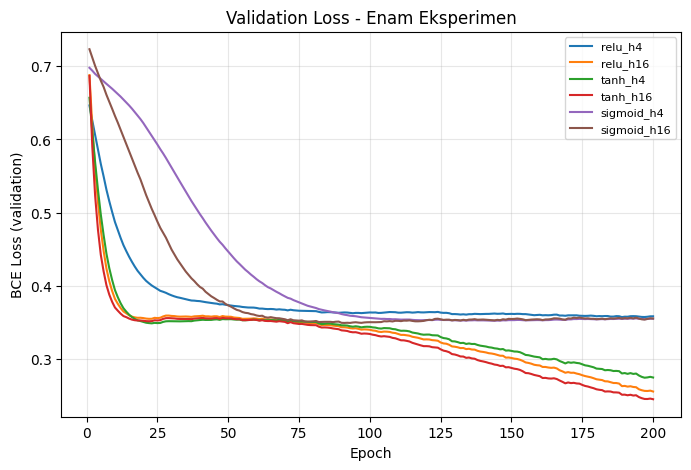

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
for run_id, history in histories.items():
    ax.plot(history['epoch'], history['val_loss'], label=run_id)
ax.set(title='Validation Loss - Enam Eksperimen', xlabel='Epoch', ylabel='BCE Loss (validation)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

Model final terpilih (validation loss terendah): tanh_h16
run_id            tanh_h16
activation            tanh
hidden_size             16
n_params                65
train_loss           0.187
train_accuracy       0.925
val_loss            0.2453
val_accuracy        0.9167
train_time_sec      3.4722
Name: 0, dtype: object

Test loss     : 0.1690
Test accuracy : 0.9500

Metrik akhir (6 eksperimen, test_metric hanya terisi untuk model final) disimpan ke M01_0005_metrics.csv


,run_id,module,student_id,seed,dataset,split,model,optimizer,learning_rate,batch_size,epochs,train_loss,val_loss,val_metric,test_metric,parameters,trainable_parameters,runtime_seconds,device,notes
0,tanh_h16,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-16-1),SGD,0.05,32,200,0.1870,0.2453,0.9167,0.95,65,65,3.4722,cuda,activation=tanh; hidden_size=16; SELECTED_FINA...
1,relu_h16,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-16-1),SGD,0.05,32,200,0.2009,0.2558,0.9000,NaN,65,65,3.2044,cuda,activation=relu; hidden_size=16
2,tanh_h4,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-4-1),SGD,0.05,32,200,0.2288,0.2750,0.9083,NaN,17,17,3.2855,cuda,activation=tanh; hidden_size=4
3,sigmoid_h4,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-4-1),SGD,0.05,32,200,0.3304,0.3551,0.8500,NaN,17,17,3.1520,cuda,activation=sigmoid; hidden_size=4
4,sigmoid_h16,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-16-1),SGD,0.05,32,200,0.3229,0.3555,0.8500,NaN,65,65,3.2472,cuda,activation=sigmoid; hidden_size=16
5,relu_h4,M01,123450005,1005,"make_moons(n_samples=600, noise=0.22)","train=360 (60%), val=120 (20%), test=120 (20%)...",FNN(2-4-1),SGD,0.05,32,200,0.3026,0.3585,0.8500,NaN,17,17,3.1838,cuda,activation=relu; hidden_size=4


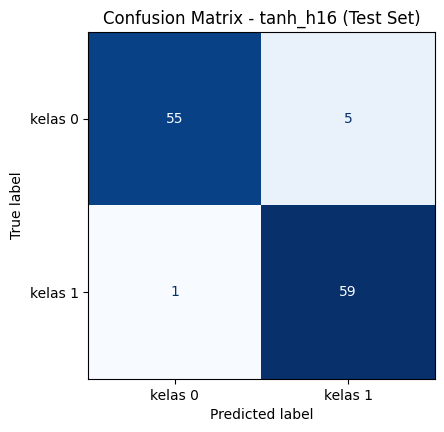

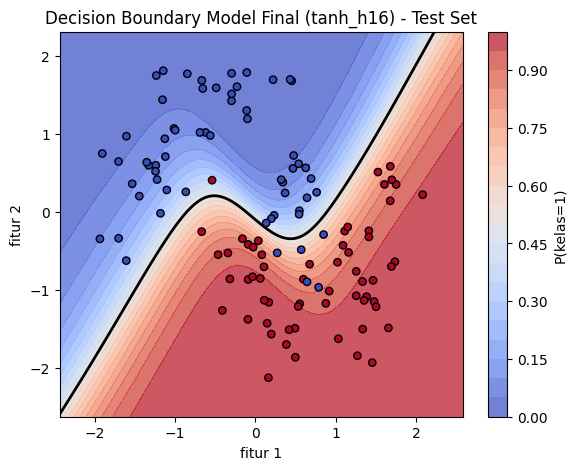

In [28]:
def plot_decision_boundary(model, X_values, y_values, title):
    model.eval()
    x_min, x_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    y_min, y_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    with torch.no_grad():
        grid_logits = model(torch.as_tensor(grid_points, dtype=torch.float32).to(DEVICE))
        grid_probabilities = torch.sigmoid(grid_logits).cpu().numpy().reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5))
    contour = ax.contourf(xx, yy, grid_probabilities, levels=20, cmap='coolwarm', alpha=0.75)
    ax.contour(xx, yy, grid_probabilities, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X_values[:, 0], X_values[:, 1], c=y_values, cmap='coolwarm', edgecolor='k', s=28)
    ax.set(title=title, xlabel='fitur 1', ylabel='fitur 2')
    fig.colorbar(contour, ax=ax, label='P(kelas=1)')
    plt.show()

best_run_id = results.iloc[0]['run_id']
best_model = trained_models[best_run_id]
print(f'Model final terpilih (validation loss terendah): {best_run_id}')
print(results.iloc[0])

test_metrics = evaluate(best_model, X_test_t, y_test_t)
print(f"\nTest loss     : {test_metrics['loss']:.4f}")
print(f"Test accuracy : {test_metrics['accuracy']:.4f}")

metrics_df.loc[metrics_df['run_id'] == best_run_id, 'test_metric'] = test_metrics['accuracy']
metrics_df.loc[metrics_df['run_id'] == best_run_id, 'notes'] = (
    metrics_df.loc[metrics_df['run_id'] == best_run_id, 'notes']
    + f"; SELECTED_FINAL_MODEL; test_loss={test_metrics['loss']:.4f}"
)
metrics_filename = f'M01_{NIM_LAST4:04d}_metrics.csv'
metrics_df.to_csv(metrics_filename, index=False)
print(f'\nMetrik akhir (6 eksperimen, test_metric hanya terisi untuk model final) disimpan ke {metrics_filename}')
display(metrics_df)

cm = confusion_matrix(y_test_f.astype(int).ravel(), test_metrics['predictions'])
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=['kelas 0', 'kelas 1']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix - {best_run_id} (Test Set)')
plt.show()

plot_decision_boundary(best_model, X_test_s, y_test, f'Decision Boundary Model Final ({best_run_id}) - Test Set')

## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.


1. **Apakah hidden size lebih besar selalu memperbaiki validation loss?**
   Hasil eksperimen menunjukkan bahwa hidden size lebih besar tidak selalu memperbaiki validation loss secara berarti. Pada aktivasi ReLU dan Tanh, peningkatan hidden size dari 4 menjadi 16 memang menurunkan validation loss secara jelas (Tanh turun dari 0,2750 menjadi 0,2453, sedangkan ReLU turun dari 0,3585 menjadi 0,2558). Namun pada aktivasi Sigmoid, perubahan hidden size dari 4 menjadi 16 hampir tidak memberikan perbaikan (0,3551 dibandingkan 0,3555). Kondisi ini mengindikasikan bahwa penambahan kapasitas jaringan tidak banyak membantu apabila hambatan utamanya justru terletak pada karakteristik fungsi aktivasi yang mudah jenuh, bukan pada jumlah neuron pada hidden layer.

2. **Aktivasi mana yang paling stabil pada dua hidden size?**
   Aktivasi Tanh menunjukkan performa yang paling stabil dan konsisten unggul pada kedua ukuran hidden layer, dengan validation loss sebesar 0,2750 pada hidden size 4 dan 0,2453 pada hidden size 16. Kedua nilai tersebut termasuk yang terendah pada masing masing kelompok eksperimen. Sebaliknya, aktivasi Sigmoid menunjukkan kestabilan paling rendah karena proses konvergensinya paling lambat, ditandai dengan validation loss yang hampir sama tingginya pada kedua ukuran hidden (sekitar 0,355) dan menempati dua peringkat terbawah dari keseluruhan enam eksperimen.

3. **Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa?**
   Fenomena tersebut ditemukan pada tiga konfigurasi, yaitu sigmoid_h4, sigmoid_h16, dan relu_h4, yang seluruhnya memperoleh validation accuracy sebesar 0,850, tetapi dengan validation loss yang berbeda beda, yaitu berturut turut 0,3551, 0,3555, dan 0,3585. Perbedaan ini terjadi karena accuracy hanya menilai apakah prediksi berada pada sisi yang benar terhadap ambang batas 0,5, sedangkan binary cross entropy mengukur seberapa yakin dan tepat probabilitas yang dihasilkan oleh model. Dua model dapat sama sama menghasilkan prediksi yang benar terhadap label, namun dengan tingkat kepercayaan probabilitas yang berbeda, sehingga nilai BCE keduanya tidak identik meskipun accuracy tersebut sama.

4. **Di bagian mana decision boundary paling tidak pasti?**
   Berdasarkan plot kontur probabilitas dari model final, yaitu konfigurasi tanh_h16, wilayah dengan tingkat ketidakpastian tertinggi berada tepat di sekitar garis kontur hitam yang menandai batas keputusan, dengan probabilitas mendekati nilai netral sebesar 0,5. Wilayah ini terletak pada zona tumpang tindih antara ujung kedua bulan sabit pada dataset make_moons, tempat titik titik dari kelas 0 dan kelas 1 saling berdekatan sebagai akibat dari noise sebesar 0,22 yang ditambahkan pada dataset.

5. **Apa satu keterbatasan eksperimen ini?**
   Salah satu keterbatasan utama adalah setiap kombinasi hyperparameter hanya dilatih dengan satu seed atau satu inisialisasi bobot, yaitu seed 1005, serta menggunakan satu pembagian data yang tetap. Oleh karena proses stochastic gradient descent dan inisialisasi bobot bersifat acak, hasil validation loss dari satu kali percobaan belum tentu sepenuhnya representatif. Konfigurasi yang tampak lebih unggul maupun lebih lemah pada eksperimen ini kemungkinan turut dipengaruhi oleh faktor keberuntungan inisialisasi, sehingga perbandingan yang lebih adil sebaiknya dilakukan dengan mengulang eksperimen pada beberapa seed dan melaporkan nilai rata rata beserta standar deviasinya.

6. **Apakah hasil sesuai hipotesis awal?**
   Hasil eksperimen menunjukkan kesesuaian yang sebagian mendukung dan sebagian menolak hipotesis awal. Pada bagian A, hipotesis memprediksi bahwa konfigurasi ReLU dengan hidden size besar, yaitu 16, akan memberikan validation loss terbaik. Namun hasil aktual menunjukkan bahwa konfigurasi tanh_h16 justru menempati peringkat pertama dengan validation loss sebesar 0,2453, mengungguli relu_h16 yang memperoleh validation loss sebesar 0,2558. Dengan demikian, hipotesis mengenai pengaruh ukuran hidden layer, yaitu ukuran 16 lebih baik daripada ukuran 4, terbukti benar untuk aktivasi ReLU dan Tanh, tetapi prediksi mengenai aktivasi terbaik ternyata kurang tepat. Di sisi lain, prediksi pada bagian G yang menyatakan bahwa aktivasi individual berupa sigmoid, dipilih karena digit terakhir NIM adalah 5, akan berkonvergensi lebih lambat dan menghasilkan validation loss lebih tinggi dibandingkan baseline ReLU terbukti benar. Validation loss sigmoid sebesar 0,3557 dan validation loss baseline ReLU sebesar 0,3559 menunjukkan nilai yang berdekatan dan sama sama lebih tinggi dibandingkan Tanh, sehingga mengonfirmasi bahwa kedua aktivasi tersebut memang kurang optimal pada eksperimen ini.

## Checklist pengumpulan - 5 poin reproduksibilitas

- [v] Identitas, seed, versi library, dan device tercantum.
- [v] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [v] Enam eksperimen tercatat pada notebook dan CSV.
- [v] Test set hanya dipakai untuk model final.
- [v] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [v] Notebook lolos Restart Kernel and Run All.
- [v] Tidak ada path absolut atau data pribadi.
- [v] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** Efi Defiyati (15 September 2026)